# Многоклассовая классификация (`OVR` и `multinomial`)

In [79]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.multiclass import OneVsRestClassifier

In [80]:
RANDOM_STATE = 42
TRAIN_SIZE = 0.75

In [81]:
data = load_iris(as_frame = True)

In [82]:
X = data.data
y = data.target

In [83]:
y

0      0
1      0
2      0
3      0
4      0
      ..
145    2
146    2
147    2
148    2
149    2
Name: target, Length: 150, dtype: int64

In [84]:
y.value_counts()

target
0    50
1    50
2    50
Name: count, dtype: int64

In [7]:
# Разобьем данные на трейн и тест

Xtrain, Xtest, ytrain, ytest = train_test_split(X, y, 
                                               train_size = TRAIN_SIZE, 
                                               random_state = RANDOM_STATE)

Применим логистическую регрессию для решения задачи.

У этой модели есть гиперпараметр `multi_class`, который может принимать значения:
* `ovr`
* `multinomial`

`ovr` - это сведение многоклассовой задаче к серии бинарных методом `one-versus-rest`

`multinomial` - это решение исходной задачи путем обобщения функции потерь логистической регрессии на многоклассовый случай (в многоклассовом случае используется функция потерь под названием [кросс-энтропия](https://en.wikipedia.org/wiki/Logistic_regression)).



Сначала используем опцию `ovr`.  
Обучим модель на тренировочных данных, сделаем предсказания на тесте и оценим качество по метрике *accuracy*.

In [13]:
model_ovr = OneVsRestClassifier(LogisticRegression())

model_ovr.fit(Xtrain, ytrain)

pred_ovr = model_ovr.predict(Xtest)

accuracy_ovr = accuracy_score(ytest, pred_ovr)

print(f'Accuracy of Logistic Regression with OVR is {accuracy_ovr}')

Accuracy of Logistic Regression with OVR is 0.9736842105263158


Теперь используем подход multinomial

In [17]:
model_mn = LogisticRegression(max_iter = 1000)

model_mn.fit(Xtrain, ytrain)

pred_mn = model_mn.predict(Xtest)

accuracy_mn = accuracy_score(ytest, pred_mn)

print(f'Accuracy of Logistic Regression with Multinomial is {accuracy_mn}')

Accuracy of Logistic Regression with Multinomial is 1.0


Параметр `max_iter` = 1000 в логистической регрессии из библиотеки scikit-learn задаёт максимальное количество итераций, которое может выполнить алгоритм оптимизации для поиска оптимальных весов модели.

Подход с опцией `multinomial` сработал в этой задаче лучше. 

Однако, это не означает, что он всегда будет работать лучше.

In [18]:
# Посмотрим на другие метрики

print(classification_report(ytest, pred_ovr))

print(classification_report(ytest, pred_mn))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        15
           1       1.00      0.91      0.95        11
           2       0.92      1.00      0.96        12

    accuracy                           0.97        38
   macro avg       0.97      0.97      0.97        38
weighted avg       0.98      0.97      0.97        38

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        15
           1       1.00      1.00      1.00        11
           2       1.00      1.00      1.00        12

    accuracy                           1.00        38
   macro avg       1.00      1.00      1.00        38
weighted avg       1.00      1.00      1.00        38



Модель `OVR` путает между собой ирисы типа 1 и 2, тип 0 находит идеально

*Значения `micro avg` равны `0,97`, поэтому они тут не отображаются*

Модель `Multinomial` отработала идеально

*В колонке `support` показано, сколько объектов какому классу принадлежат*

# Метод ближайших соседей (K-Nearest-Neighbors, KNN)

## Импорт библиотек, установка константных значений

In [19]:
import numpy as np
import pandas as pd
import sklearn

from sklearn.datasets import load_digits
from sklearn.neighbors import KNeighborsClassifier
from sklearn.utils import shuffle
from sklearn.metrics import accuracy_score

from matplotlib import pyplot as plt

In [20]:
RANDOM_STATE = 42
TRAIN_SIZE = 0.75

## Практика

Применим KNN к датасету с изображениями цифр. Это данные для 10-классовой классификации.

Загрузим данные и посмотрим на них.

In [86]:
data = load_digits()

X = data.images
y = data.target

X.shape # У нас 1797 объектов, а каждый объект - это картинка 8 на 8 пикселей

(1797, 8, 8)

In [87]:
pd.Series(y).value_counts()

3    183
1    182
5    182
4    181
6    181
9    180
7    179
0    178
2    177
8    174
Name: count, dtype: int64

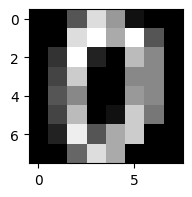

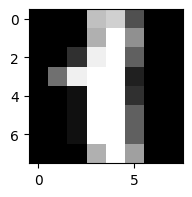

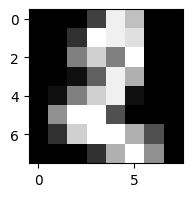

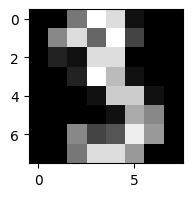

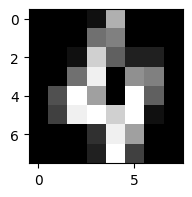

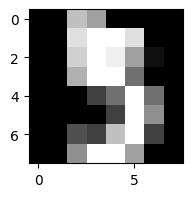

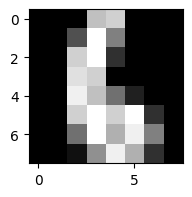

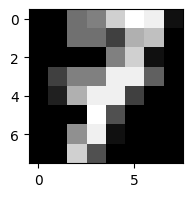

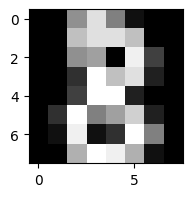

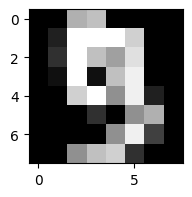

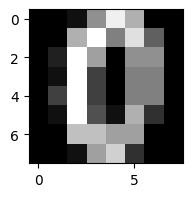

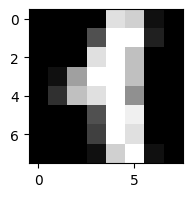

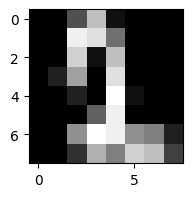

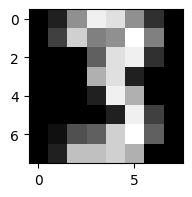

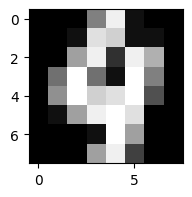

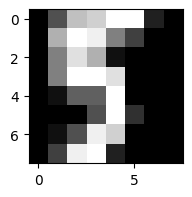

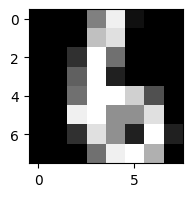

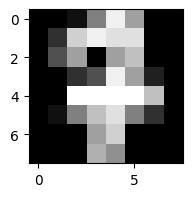

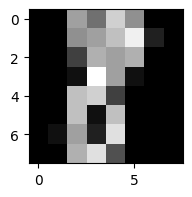

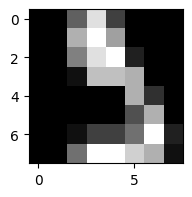

In [70]:
for i in range(20):
    plt.figure(figsize = (2, 2))
    plt.imshow(X[i], cmap = 'gray')
    plt.show()

Каждая картинка - это матрица из чисел, где число - это яркость соответствующего пикселя

Вытянем каждую картинку 8 * 8 в вектор размера 64
Тогда в матрице объект-признак каждая строчка - это будет одна картинка

In [62]:
X = X.reshape(X.shape[0], -1)

В исходном датасете данные идут по порядку: 0, 1, 2, ...

Перемешаем данные, т к нам для обучения и тестирования модели нужен случайный порядок

In [63]:
X, y = shuffle(X, y)

print(f'Features shape: {X.shape},\nTarget shape: {y.shape}')
print(f'Target samples: {y[:10]}')

Features shape: (1797, 64),
Target shape: (1797,)
Target samples: [3 1 9 8 5 7 3 7 9 7]


Разобьем данные на трейн и тест

In [64]:
Xtrain, Xtest, ytrain, ytest = train_test_split(X, y, 
                                               train_size = TRAIN_SIZE, 
                                               random_state = RANDOM_STATE)

Обучим KNN с взятым из головы числом соседей (10)

In [49]:
clf = KNeighborsClassifier(n_neighbors=10)

clf.fit(Xtrain, ytrain) # обучение модели заключается в том, что модель просто запоминает всю обучающую выборку
pred_clf = clf.predict(Xtest)

accuracy_clf = accuracy_score(ytest, pred_clf)

In [50]:
print(f'Accuracy is {accuracy_clf}')

Accuracy is 0.9733333333333334


Посмотрим, как число соседей влияет на качество модели

По хорошему гиперпараметры (количество соседей) надо подбирать на валидации, но тут чисто для демонстрации

In [51]:
for k in np.arange(3, 20, 3):
    clf_k = KNeighborsClassifier(n_neighbors=k)

    clf_k.fit(Xtrain, ytrain)
    pred_clf_k = clf_k.predict(Xtest)
    
    accuracy_clf_k = accuracy_score(ytest, pred_clf_k)

    print(f'Accuracy with {k} neighbors is {accuracy_clf_k}')

Accuracy with 3 neighbors is 0.98
Accuracy with 6 neighbors is 0.9777777777777777
Accuracy with 9 neighbors is 0.9777777777777777
Accuracy with 12 neighbors is 0.9711111111111111
Accuracy with 15 neighbors is 0.9733333333333334
Accuracy with 18 neighbors is 0.9688888888888889


#### Классический KNN никак не учитывает веса соседей: `по умолчанию weights = 'uniform'`

#### Посмотрим, как влияет на качество алгоритма способ учесть веса у ближайших соседей

In [52]:
for weights in ['uniform', 'distance']:
    clf_w = KNeighborsClassifier(n_neighbors=3, weights=weights)

    clf_w.fit(Xtrain, ytrain)
    pred_clf_w = clf_w.predict(Xtest)
    
    accuracy_clf_w = accuracy_score(ytest, pred_clf_w)

    print(f'Accuracy with {weights} weights is {accuracy_clf_w}')

Accuracy with uniform weights is 0.98
Accuracy with distance weights is 0.9822222222222222


## Визуально оценим качество предсказаний

predicted label: 5


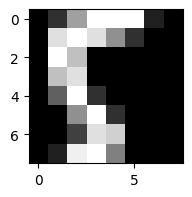

predicted label: 3


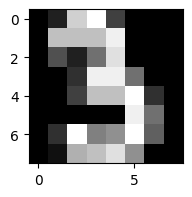

predicted label: 0


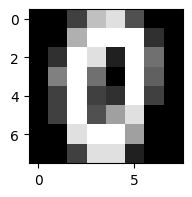

predicted label: 9


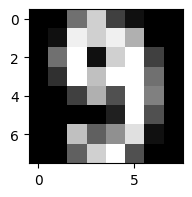

predicted label: 7


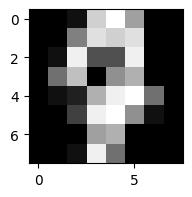

In [54]:
for i in range(5):
  print('predicted label:', pred_clf_w[i])
  plt.figure(figsize=(2,2))
  plt.imshow(Xtest[i].reshape((8,8)), cmap='gray')
  plt.show()

# Какие есть гиперпараметры в KNN

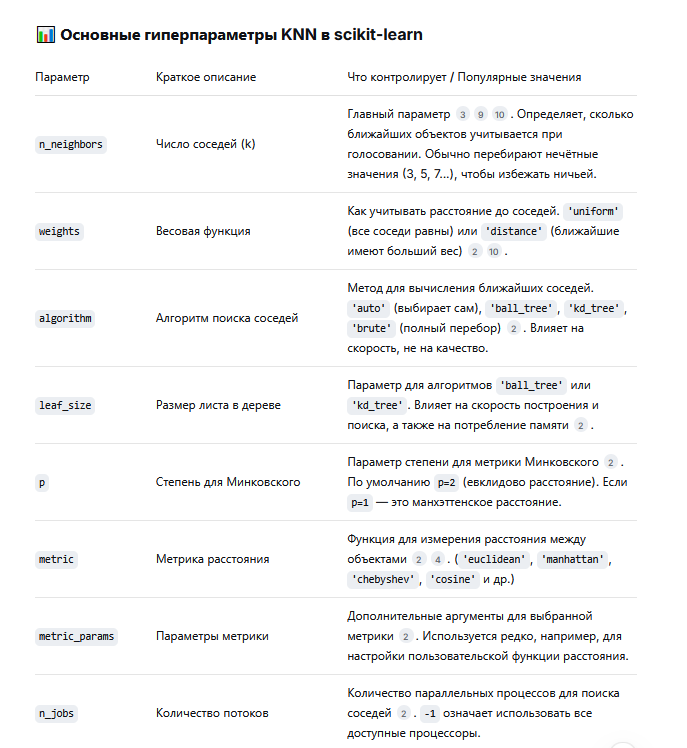

# Метрики расстояния: `по умолчанию metric='minkowski', p=2`

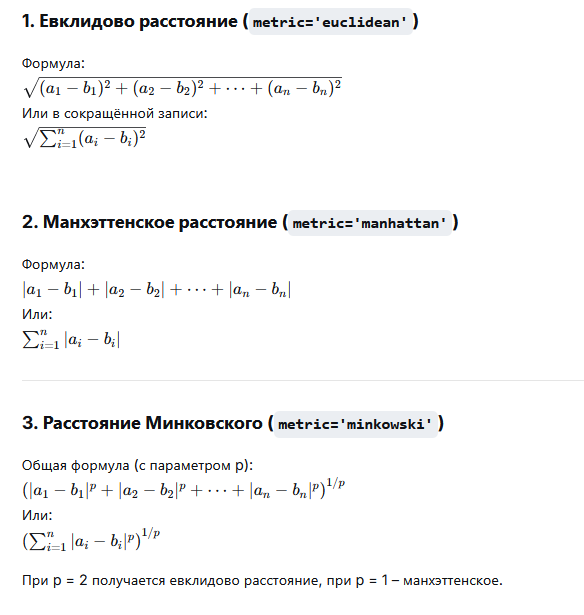

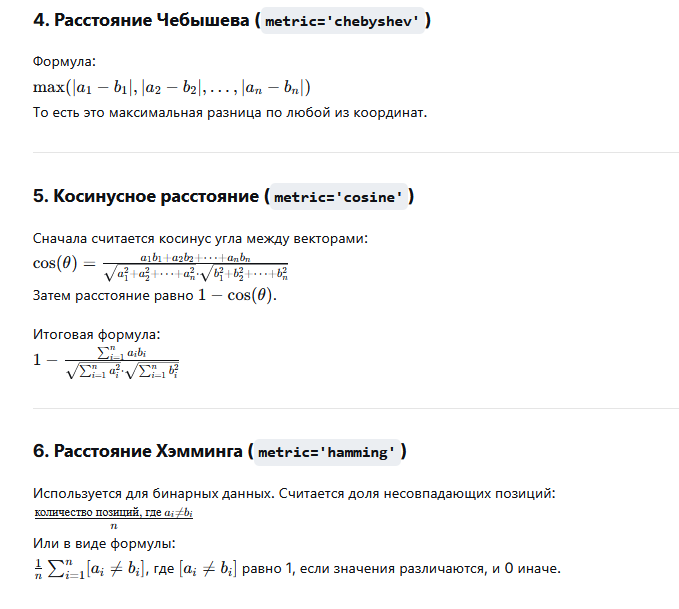

# Функция веса: `по умолчанию weights = 'uniform'`

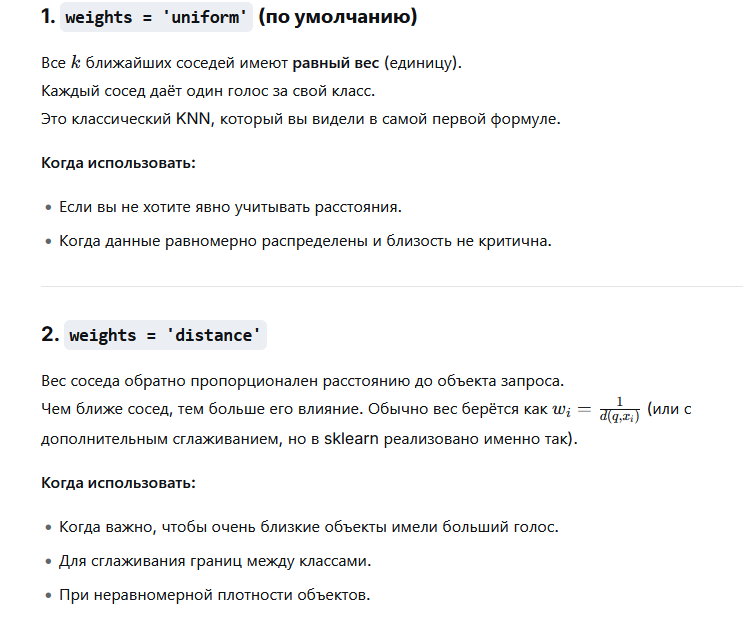

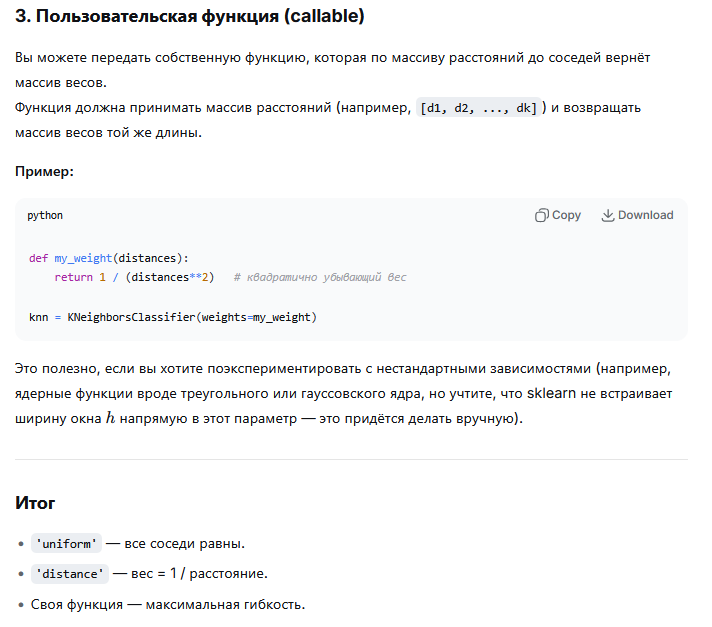

# KNN с использованием LSH (Быстрый поиск соседей)

In [88]:
import numpy as np

RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)

Для демонстрации сгенерируем датасет из нормального распределения, где $m$ - число объектов, $n$ - число признаков.

In [169]:
m = 100000
n = 10000

$q$ - вектор запроса (query), для которого мы ищем ближайших соседей.

In [170]:
X = rng.normal(size = (m, n))  # датасет
q = rng.normal(size = n)       # вектор запроса (некоторый случайный вектор)

## Поиск с помощью стандартного KNN

In [171]:
def knn_search(query, data, k=5):

    dists = np.sqrt(np.sum((data - query) ** 2, axis=1))  # вычисляем расстояния от объекта query до всех точек датасета
    inds = np.argsort(dists)  # сортируем по возрастанию расстояний
    inds_k = inds[:k]         # берем top-k точек с наименьшими расстояниями

    return data[inds_k], dists[inds_k]



Найдем 5 ближайших соседей методом KNN.

Также замерим время работы поиска.


In [172]:
%%time

neighbors, dists = knn_search(q, X)
for i, (neighbor, dist) in enumerate(zip(neighbors, dists)):
    print(f"top {i + 1}: dist = {dist}")

top 1: dist = 138.16075386066052
top 2: dist = 138.18518549253616
top 3: dist = 138.4127987365534
top 4: dist = 138.4816067289409
top 5: dist = 138.5027008088681
CPU times: total: 13.7 s
Wall time: 13.8 s


## KNN с использованием LSH

Идея метода состоит в том, что:
* Сначала при помощи LSH отбираем объекты, похожие на объект query
* Затем при помощи KNN ищем ближайшие объекты к query только среди похожих, найденных на предыдущем шаге

Используем метод LSH с кодированием при помощи случайных проекций. Он состоит в следующем:
* проводим несколько случайных гиперплоскостей
* для каждой плоскости: для каждого объекта ставим 1, если объект лежит выше плоскости, и 0 иначе
* тогда каждый объект кодируется вектором из 0 и 1, где длина вектора равна числу сгенерированных гиперплоскостей

Объекты похожи, если их кодировки совпадают.

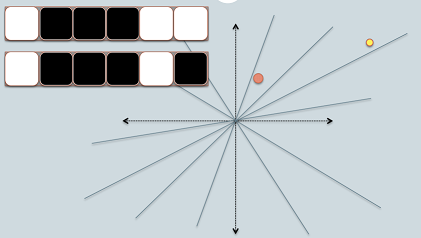

Следующая функция вычисляет количество случайных гиперплоскостей и генерирует их, основываясь на том, сколько в среднем мы хотим получать объектов в одной корзине после хеширования (`bucket_size`).

In [173]:
def generate_hyperplanes(data, bucket_size=16):
    m = data.shape[0]            # число объектов
    n = data.shape[1]            # число признаков
    b = m // bucket_size         # количество корзин
    h = int(np.log2(b))          # количество гиперплоскостей
    H = rng.normal(size=(h, n))  # гиперплоскости, заданные своими нормалями
    return H

Следующая функция хеширует данные, основываясь на полученных гиперплоскостях, то есть кодирует объект вектором из 0 и 1.

Затем для удобства функция переводит вектор в число путем перевода из двоичной системы в десятичную.

Например: $[0, 1, 1, 0] \to 0 \cdot 1 + 1 \cdot 2 + 1 \cdot 4 + 0 \cdot 8 = 6$

Между двоичной и десятичной записью взаимно однозначное соответствие, но десятичная запись удобнее.  
По сути полученное число - это номер корзины, в которую попадает объект.

In [174]:
def hamming_hash(data, hyperplanes):
    b = len(hyperplanes)
    hash_key = (data @ hyperplanes.T) >= 0

    dec_vals = np.array([2 ** i for i in range(b)], dtype=int)
    hash_key = hash_key @ dec_vals

    return hash_key

Теперь мы умеем по каждому объекту определять номер корзины, в которую он попадает.

Функция ниже создает словарь, где для каждой корзины содержатся элементы выборки, попадающие в эту корзину  
(эта структура называется *хеш-таблицей*).

In [175]:
def locality_sensitive_hash(data, hyperplanes):
    hash_vals = hamming_hash(data, hyperplanes)
    hash_table = {}
    for i, v in enumerate(hash_vals):
        if v not in hash_table:
            hash_table[v] = set()
        hash_table[v].add(i)

    return hash_table

Посмотрим, как работают описанные функции.

In [176]:
hyperplanes = generate_hyperplanes(X)

print('num planes:',len(hyperplanes))
print('normal vector to 1st plane:',hyperplanes[0])

num planes: 12
normal vector to 1st plane: [-0.35327895 -0.1115533   0.10029345 ...  0.70895511 -1.50096947
  1.0183576 ]


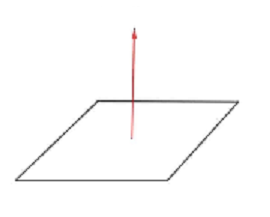

In [177]:
hamming_hash(q, hyperplanes)

np.int64(2811)

In [178]:
hash_table = locality_sensitive_hash(X, hyperplanes)
#hash_table

Теперь реализуем алгоритм поиска KNN с использованием LSH:
* Сначала при помощи LSH отбираем объекты, похожие на объект query
* Затем при помощи KNN ищем ближайшие объекты к query только среди похожих, найденных на предыдущем шаге

In [120]:
def approx_knn_search(query, data, k=5, bucket_size=16):
    candidates = set()

    hyperplanes = generate_hyperplanes(data)
    hash_table = locality_sensitive_hash(data, hyperplanes) # формируем хеш-таблицу по датасету

    query_hash = hamming_hash(query, hyperplanes)
    if query_hash in hash_table:
        candidates = candidates.union(hash_table[query_hash])
    candidates = np.stack([data[i] for i in candidates], axis=0) # находим кандидатов = объекты, попадающие с query в одну корзину

    return knn_search(query, candidates, k=k) # с помощью KNN ищем ближайших соседей только из найденных кандидатов

In [122]:
%%time

neighbors, dists = approx_knn_search(q, X)

for i, (neighbor, dist) in enumerate(zip(neighbors, dists)):
    print(f"top {i + 1}: dist = {dist}")

top 1: dist = 140.31428930207525
top 2: dist = 140.39807064781112
top 3: dist = 140.43629077260127
top 4: dist = 140.53523846151634
top 5: dist = 141.01064833208278
CPU times: total: 12.8 s
Wall time: 1.61 s


##  В этом домашнем задании вы будете решать задачу классификации бутылок вина по различным характеристикам


In [195]:
import pandas as pd
import numpy as np

In [196]:
RANDOM_STATE = 42
TRAIN_SIZE = 0.75

In [197]:
rng = np.random.default_rng(RANDOM_STATE)

### Загрузка данных

In [198]:
from sklearn.datasets import load_wine

data =  load_wine(as_frame = True)

X = data.data
y = data.target

## Задание 1

**Вопрос**:  
Сколько классов в задаче?

In [199]:
len(y.value_counts())

3

## Задание 2

Мы имеем дело с многоклассовой классификацией. Кроме того, классы не очень хорошо сбалансированы, поэтому для оценки качества модели метрика *accuracy* не подойдет.

Разбейте данные на тренировочную и тестовую части:  
тестовая часть - 25% от всех данных, зафиксируйте `random_state = RANDOM_STATE`.


In [200]:
from sklearn.model_selection import train_test_split

Xtrain, Xtest, ytrain, ytest = train_test_split(X, y, random_state = RANDOM_STATE, train_size=TRAIN_SIZE)

**Вопрос:**

Все ли признаки в данных одного масштаба?  
Проверьте это, выведя основные числовые характеристики матрицы `X_train` методом `describe` из библиотеки `pandas`.

По полученной таблице числовых характеристик определите, какой признак измеряется в сотнях?  
(если вариантов несколько, выберите признак с наибольшим средним значением).

In [201]:
Xtrain.describe()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
count,133.000000,133.000000,133.000000,133.000000,133.000000,133.000000,133.000000,133.000000,133.000000,133.000000,133.000000,133.000000,133.000000
mean,12.972857,2.386842,2.362180,19.433835,100.759398,2.277068,2.021203,0.363534,1.608647,5.017594,0.959444,2.610000,742.992481
std,0.829993,1.098905,0.280606,3.467312,14.999571,0.645696,1.005537,0.126923,0.576964,2.202516,0.234545,0.729961,306.867593
min,11.030000,0.890000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.420000,1.740000,0.480000,1.270000,278.000000
25%,12.290000,1.640000,2.210000,17.200000,88.000000,1.700000,1.200000,0.260000,1.250000,3.250000,0.780000,1.830000,500.000000
50%,12.990000,1.900000,2.360000,19.400000,98.000000,2.230000,2.140000,0.340000,1.560000,4.800000,0.970000,2.810000,675.000000
75%,13.690000,3.170000,2.540000,21.500000,108.000000,2.800000,2.880000,0.450000,1.960000,6.130000,1.120000,3.200000,970.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,10.800000,1.710000,4.000000,1547.000000


## Задание 3

KNN требует того, чтобы все признаки были одного масштаба, поэтому масштабируйте данные при помощи `StandardScaler`.

Напоминаем, что обучать метод нужно только по тренировочным данным, а применять и к трейну, и к тесту.

После применения `StandardScaler` преобразуйте `X_train` и `X_test` к типу `pd.DataFrame`, названия новых объектов оставьте `X_train` и `X_test`.

In [202]:
from sklearn.preprocessing import StandardScaler

ss = StandardScaler()

ss.fit(Xtrain)

Xtrain = pd.DataFrame(ss.transform(Xtrain), columns = X.columns)
Xtest = pd.DataFrame(ss.transform(Xtest), columns = X.columns) 

Обучите KNN с параметрами по умолчанию на тренировочных данных и сделайте предсказание на тесте.

In [203]:
from sklearn.neighbors import KNeighborsClassifier

knc = KNeighborsClassifier()

knc.fit(Xtrain, ytrain)

pred_knc = knc.predict(Xtest)

Будем измерять качество модели по метрике weighted $f1$-score.

Чтобы выбрать тип усреднения (micro, macro, weighted) в функции `f1_score` необходимо задать этот тип в гиперпараметре `average`.

Вычислите $f1$-score на тестовых данных.

**Вопрос:**

Чему равен $f1$-score на тестовых данных?

In [204]:
from sklearn.metrics import f1_score

f1_knc = f1_score(ytest, pred_knc, average = 'weighted')

print(f'weighted f1_score for knc is {f1_knc}')

weighted f1_score for knc is 0.9550512333965844


## Задание 4

Попробуем улучшить модель.

Подберите оптимальное количество соседей (`n_neighbors`) из диапазона *от 3 до 30 с шагом 2* и веса соседей (`weights`):  
`uniform`, `distance` по кросс-валидации с тремя фолдами на тренировочных данных.

Используйте `GridSearchCV` и метрику `f1_weighted`.

In [205]:
from sklearn.model_selection import GridSearchCV

params = {'n_neighbors' : np.arange(3, 30, 2), 'weights' : ['uniform', 'distance']}

gs = GridSearchCV(KNeighborsClassifier(), params, cv = 3, scoring = 'f1_weighted')

gs.fit(Xtrain, ytrain)

bs = gs.best_score_
bp = gs.best_params_

print(bs) # качество наилучшей модели (с оптимальными гиперпараметрами)
print(bp) # оптимальные гиперпараметры

0.9623290498688742
{'n_neighbors': np.int64(19), 'weights': 'distance'}


**Вопрос:**

Удалось ли при помощи подбора гиперпараметров улучшить качество модели на тестовых данных?

In [206]:
knc = KNeighborsClassifier(n_neighbors = 19, weights = 'distance')

knc.fit(Xtrain, ytrain)

pred_knc = knc.predict(Xtest)

f1_knc = f1_score(ytest, pred_knc, average = 'weighted')

print(f'weighted f1_score for knc with best parameters is {f1_knc}')

weighted f1_score for knc with best parameters is 0.9550512333965844


## Задание 5

Выведите на экран матрицу ошибок.

Используйте модель с подобранными при помощи `GridSearch` гиперпараметрами.


**Вопрос:**  
По этой матрице определите, какие классы между собой путает модель?

In [209]:
# Когда вносишь изменения в файл utils (меняешь названия функций, добавляешь новые), запускай этот код и все изменения подгрузятся

import importlib
import utils          # импортируем сам модуль (если ещё не импортирован)
importlib.reload(utils)

<module 'utils' from 'C:\\Users\\1\\practical ml\\utils.py'>

In [149]:
from sklearn.metrics import confusion_matrix

confusion_matrix(ytest, pred_knc)

array([[15,  0,  0],
       [ 1, 16,  1],
       [ 0,  0, 12]])

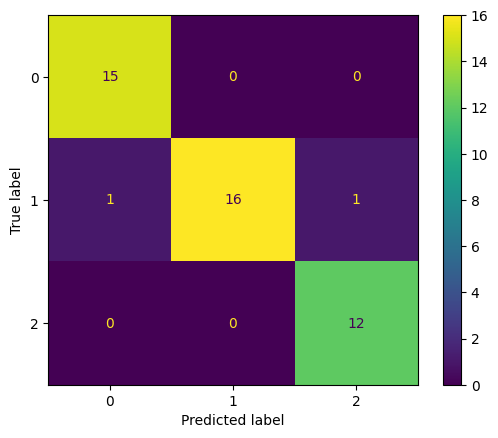

In [153]:
#Посмотрим на матрицу ошибок (confusion matrix)
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(ytest, pred_knc)
plt.show()

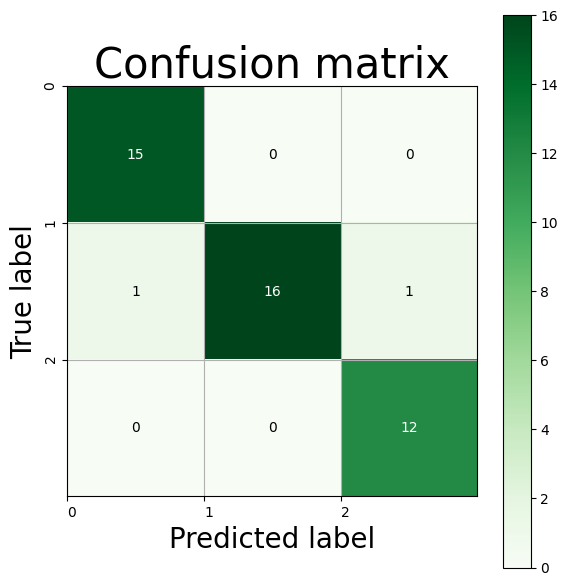

In [210]:
from utils import plot_confusion_matrix

plot_confusion_matrix(ytest, pred_knc, ['0', '1', '2'])

In [215]:
type(ytest.value_counts())

pandas.Series

In [216]:
ytest.value_counts()

target
1    18
0    15
2    12
Name: count, dtype: int64

In [217]:
ytest.value_counts().index.tolist()

[1, 0, 2]

## Бонус (эксперименты с LSH)

In [219]:
def knn_search(query, data, k=5):

    dists = np.sqrt(np.sum((data - query) ** 2, axis=1))  # вычисляем расстояния от объекта query до всех точек датасета
    inds = np.argsort(dists)  # сортируем по возрастанию расстояний
    inds_k = inds[:k]         # берем top-k точек с наименьшими расстояниями

    return data[inds_k], dists[inds_k]

def generate_hyperplanes(data, bucket_size=16):
    m = data.shape[0]            # число объектов
    n = data.shape[1]            # число признаков
    b = m // bucket_size         # количество корзин
    h = int(np.log2(b))          # количество гиперплоскостей
    H = rng.normal(size=(h, n))  # гиперплоскости, заданные своими нормалями
    return H

def hamming_hash(data, hyperplanes):
    b = len(hyperplanes)
    hash_key = (data @ hyperplanes.T) >= 0

    dec_vals = np.array([2 ** i for i in range(b)], dtype=int)
    hash_key = hash_key @ dec_vals

    return hash_key

def locality_sensitive_hash(data, hyperplanes):
    hash_vals = hamming_hash(data, hyperplanes)
    hash_table = {}
    for i, v in enumerate(hash_vals):
        if v not in hash_table:
            hash_table[v] = set()
        hash_table[v].add(i)

    return hash_table

def approx_knn_search(query, data, k=5, bucket_size=16):
    candidates = set()

    hyperplanes = generate_hyperplanes(data)
    hash_table = locality_sensitive_hash(data, hyperplanes) # формируем хеш-таблицу по датасету

    query_hash = hamming_hash(query, hyperplanes)
    if query_hash in hash_table:
        candidates = candidates.union(hash_table[query_hash])
    candidates = np.stack([data[i] for i in candidates], axis=0) # находим кандидатов = объекты, попадающие с query в одну корзину

    return knn_search(query, candidates, k=k) # с помощью KNN ищем ближайших соседей только из найденных кандидатов

При помощи `knn_search` найдите ближайших соседей к вину `X_test.iloc[0]` в **тренировочных** данных.

Обратите внимание, что функция `knn_search` принимает на вход `np.array`, а не `pd.DataFrame`. Поэтому переведите аргументы в `np.array`, приписав к необходимому объекту $X$: `X.values`.

In [236]:
%%time

neighbors, dists = knn_search(Xtest.iloc[0].values, Xtrain.values)
for i, (neighbor, dist) in enumerate(zip(neighbors, dists)):
    print(f"top {i + 1}: dist = {dist}")

top 1: dist = 1.7873320988662764
top 2: dist = 1.980962405259275
top 3: dist = 2.1601016426727617
top 4: dist = 2.2709745642534576
top 5: dist = 2.3117955237515453
CPU times: total: 0 ns
Wall time: 0 ns


In [235]:
%%time

neighbors, dists = approx_knn_search(Xtest.iloc[0].values, Xtrain.values)
for i, (neighbor, dist) in enumerate(zip(neighbors, dists)):
    print(f"top {i + 1}: dist = {dist}")

top 1: dist = 1.7873320988662762
top 2: dist = 1.980962405259275
top 3: dist = 2.1601016426727617
top 4: dist = 2.2709745642534576
top 5: dist = 2.3117955237515457
CPU times: total: 0 ns
Wall time: 0 ns
